In [ ]:
pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ismailismailtijjani/naira-nigerian-currency-dataset")

print("Path to dataset files:", path)

100%|██████████| 179M/179M [00:10<00:00, 18.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ismailismailtijjani/naira-nigerian-currency-dataset/versions/1


In [ ]:
import os

# List the contents of the downloaded dataset directory
dataset_path = path  # 'path' variable is available from previous execution
print(f"Contents of the dataset directory '{dataset_path}':")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Contents of the dataset directory '/root/.cache/kagglehub/datasets/ismailismailtijjani/naira-nigerian-currency-dataset/versions/1':
1/
    NAIRA DATASET/
        Train/
            1000/
                1000_9.JPG
                1000_92.JPG
                1000_95.JPG
                1000_124.JPG
                1000_182.JPG
                1000_188.JPG
                1000_157.JPG
                1000_164.JPG
                1000_172.JPG
                1000_111.JPG
                1000_200.JPG
                1000_88.JPG
                1000_199.JPG
                1000_56.JPG
                1000_97.JPG
                1000_86.JPG
                1000_130.JPG
                1000_107.JPG
                1000_102.JPG
                1000_70.JPG
                1000_100.JPG
                1000_158.JPG
                1000_83.JPG
                1000_69.JPG
                1000_167.JPG
                1000_175.JPG
                1000_163.JPG
                1000_197.JPG
            

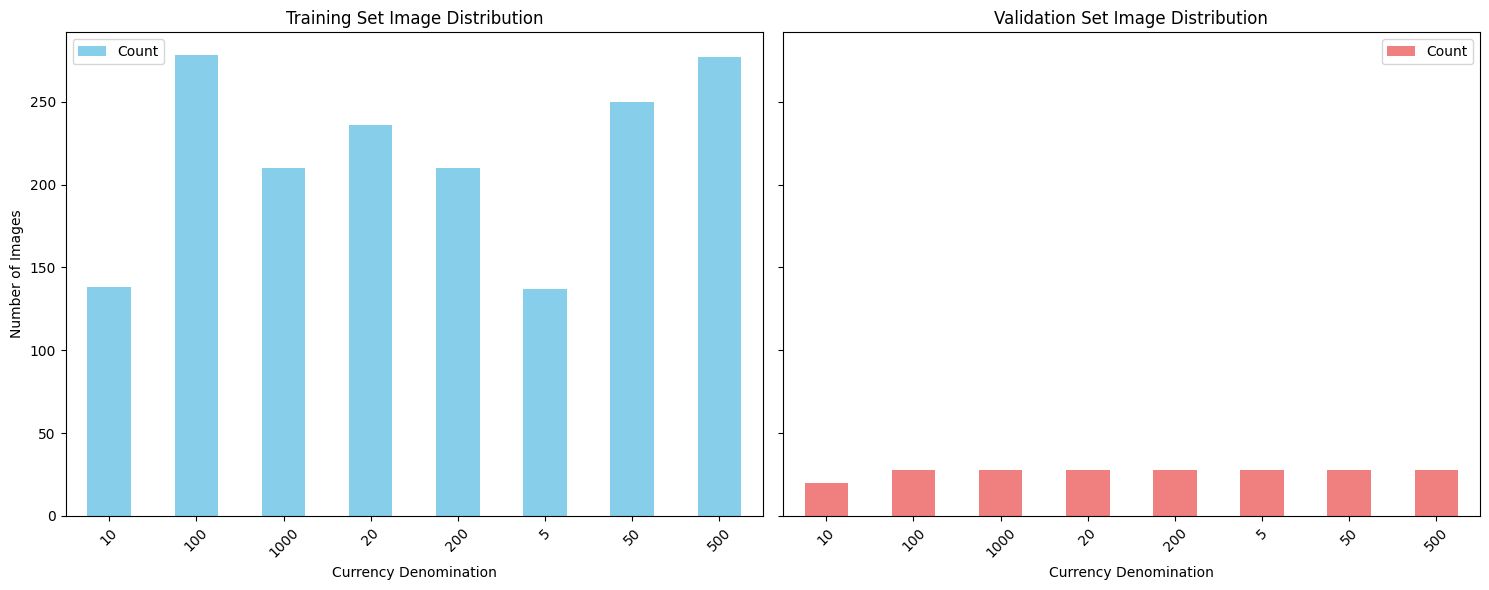

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for plotting
train_df = pd.DataFrame(train_counts.items(), columns=['Class', 'Count'])
val_df = pd.DataFrame(val_counts.items(), columns=['Class', 'Count'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plot training set counts
train_df.sort_values('Class').plot(kind='bar', x='Class', y='Count', ax=axes[0], color='skyblue')
axes[0].set_title('Training Set Image Distribution')
axes[0].set_xlabel('Currency Denomination')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)

# Plot validation set counts
val_df.sort_values('Class').plot(kind='bar', x='Class', y='Count', ax=axes[1], color='lightcoral')
axes[1].set_title('Validation Set Image Distribution')
axes[1].set_xlabel('Currency Denomination')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Data Exploration Summary and Suitability for Transfer Learning

### Data Structure
The dataset is structured as an image classification dataset, with separate directories for `Train` and `val` (validation) sets. Each of these directories contains subdirectories named after the currency denominations (e.g., '10', '20', '50', '100', '200', '500', '1000'), which serve as the class labels for the images.

### Class Distribution
*   **Training Set:** We observed varying numbers of images per class in the training set. Classes like '100' and '500' have a higher count (278 and 277 images respectively), while '5' and '10' have fewer images (137 and 138 images). This indicates some degree of class imbalance in the training data.
*   **Validation Set:** The validation set shows a more balanced distribution, with most classes having 28 images, except for '10' which has 20 images. This relatively balanced validation set is good for evaluating the model's performance across all classes.

### Suitability for Transfer Learning with MobileNetV2

This dataset is **highly suitable for transfer learning**, especially with a model like **MobileNetV2**, for the following reasons:

1.  **Image Classification Task:** Transfer learning excels in image classification tasks where pre-trained models have learned robust features from vast and diverse image datasets (like ImageNet).
2.  **Limited Data per Class:** While some classes have a decent number of images (around 200-270), others are relatively smaller (around 130 images in the training set and 20-28 in the validation set). Transfer learning is particularly effective in scenarios with limited domain-specific data, as it leverages the knowledge acquired by the pre-trained model.
3.  **MobileNetV2 Characteristics:**
    *   **Lightweight and Efficient:** MobileNetV2 is designed to be computationally efficient and small in size, making it ideal for deployment on mobile and edge devices, or when computational resources (like GPU memory) are limited. This aligns well with a potential real-world application of currency recognition on mobile phones.
    *   **Pre-trained on ImageNet:** Being pre-trained on ImageNet, MobileNetV2 has learned to detect a wide array of generic features (edges, textures, shapes), which are fundamental to recognizing objects, including currency notes.
4.  **Handling Class Imbalance:** The class imbalance in the training set can be addressed during model training using strategies common in deep learning, such as:
    *   **Data Augmentation:** Techniques like rotation, zooming, shifting, and flipping can be applied, especially to minority classes, to artificially increase their representation.
    *   **Weighted Loss Functions:** Assigning higher weights to minority classes during loss calculation can make the model pay more attention to correctly classifying them.
    *   **Resampling:** Over-sampling minority classes or under-sampling majority classes.

**Conclusion:** The dataset's structure, the nature of the image classification task, and the characteristics of MobileNetV2 make it an excellent choice for developing a robust Nigerian currency recognition model using transfer learning. The observed class imbalance can be effectively managed with standard deep learning techniques during the training phase.

In [ ]:
import os

dataset_base_path = os.path.join(dataset_path, 'NAIRA DATASET')

def count_images_per_class(base_dir):
    counts = {}
    # Check if the directory exists before listing its contents
    if not os.path.isdir(base_dir):
        print(f"Warning: Directory not found: {base_dir}")
        return counts

    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            counts[class_name] = len(image_files)
    return counts

train_path = os.path.join(dataset_base_path, 'Train')
# Correcting the path to 'val' (lowercase 'v')
val_path = os.path.join(dataset_base_path, 'val')

print("\n--- Training Set Image Counts ---")
train_counts = count_images_per_class(train_path)
for class_name, count in sorted(train_counts.items()):
    print(f"Class {class_name}: {count} images")

print("\n--- Validation Set Image Counts ---")
val_counts = count_images_per_class(val_path)
for class_name, count in sorted(val_counts.items()):
    print(f"Class {class_name}: {count} images")



--- Training Set Image Counts ---
Class 10: 138 images
Class 100: 278 images
Class 1000: 210 images
Class 20: 236 images
Class 200: 210 images
Class 5: 137 images
Class 50: 250 images
Class 500: 277 images

--- Validation Set Image Counts ---
Class 10: 20 images
Class 100: 28 images
Class 1000: 28 images
Class 20: 28 images
Class 200: 28 images
Class 5: 28 images
Class 50: 28 images
Class 500: 28 images
